# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/previsao_de_renda.csv')

In [2]:
df.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


In [5]:
df['tipo_residencia'].unique()

array(['Casa', 'Com os pais', 'Aluguel', 'Governamental', 'Estúdio',
       'Comunitário'], dtype=object)

In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True) # Example: dropping the 'Unnamed: 0' column. Set inplace=True to modify df directly.
df.dtypes

,0
index,int64
sexo,object
posse_de_veiculo,bool
posse_de_imovel,bool
qtd_filhos,int64
tipo_renda,object
educacao,object
estado_civil,object
tipo_residencia,object
idade,int64


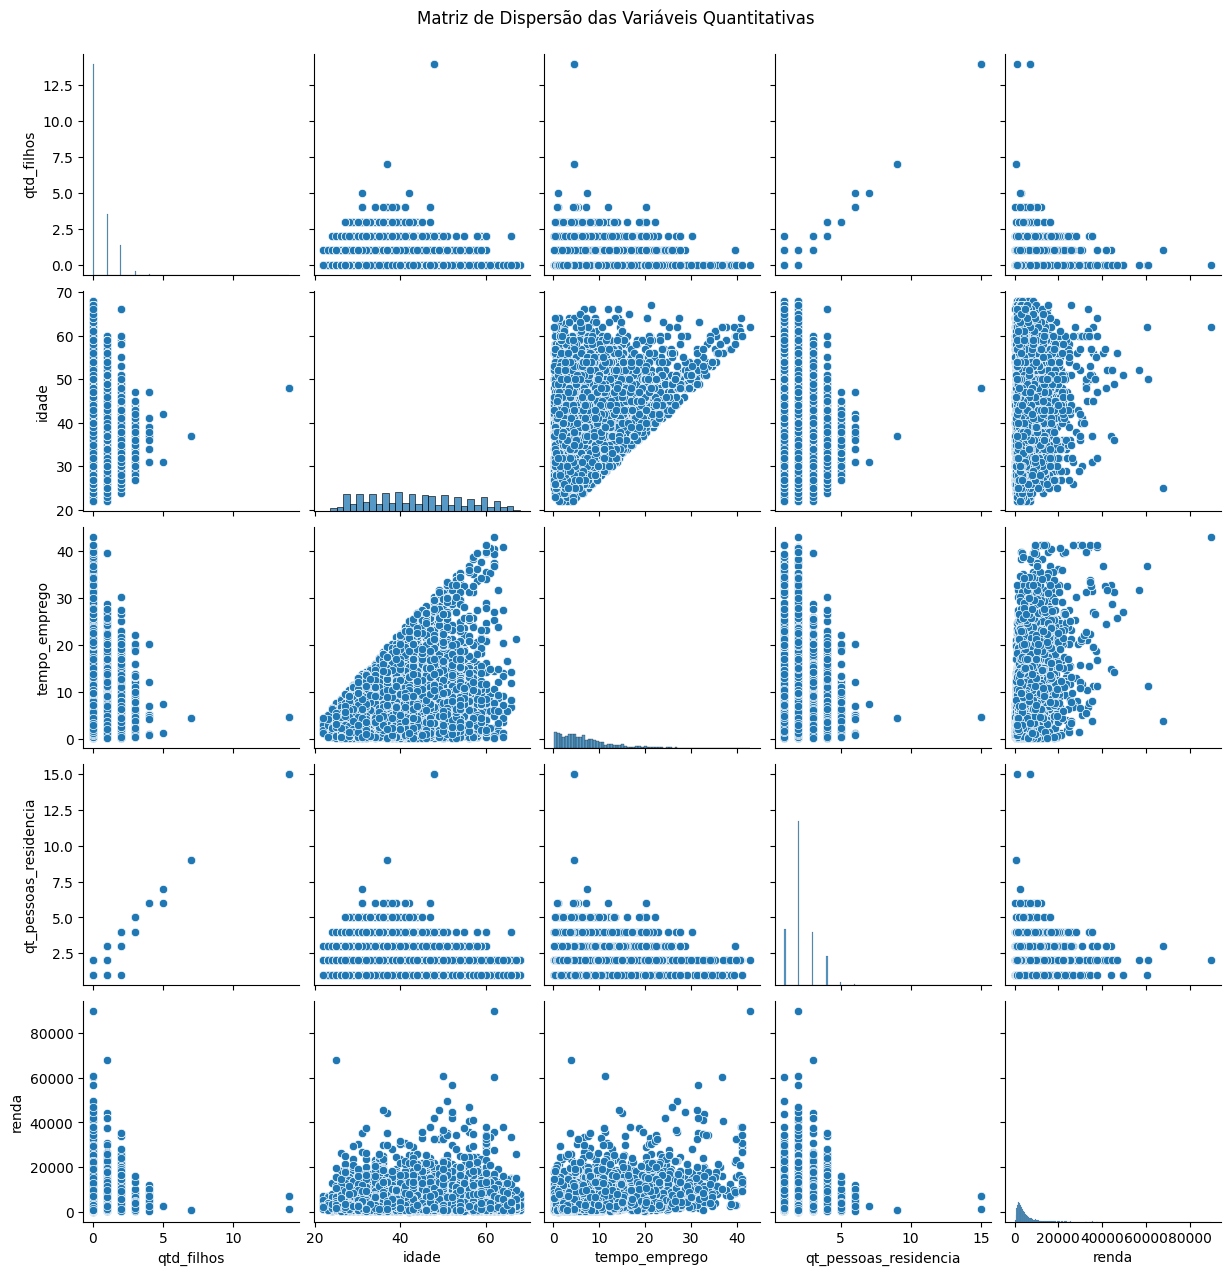

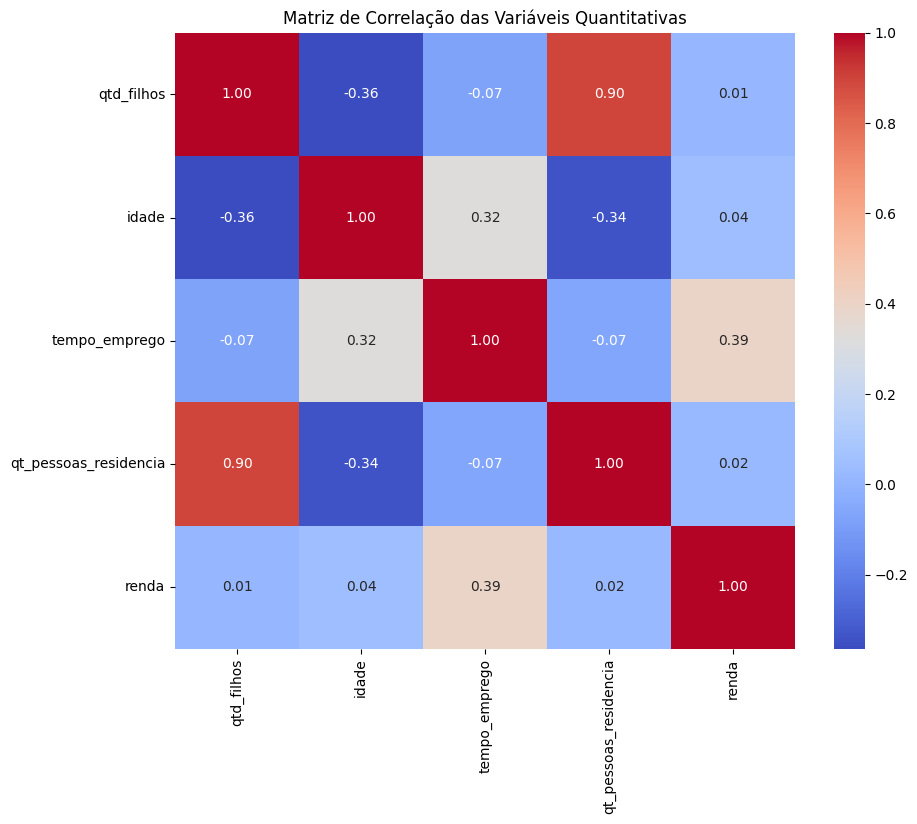

In [9]:
df = pd.read_csv('/content/previsao_de_renda.csv')

# Drop 'Unnamed: 0' if it exists (it was added by pandas upon reading the CSV)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Convert 'data_ref' to datetime, but DO NOT set it as index for correlation analysis
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Identify quantitative variables
quantitative_vars = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'index' as it's an identifier and not a true quantitative variable for correlation analysis
if 'index' in quantitative_vars:
    quantitative_vars.remove('index')

# Calculate the correlation matrix
corr_matrix = df[quantitative_vars].corr()

# Create a scatter matrix (pairplot)
sns.pairplot(df[quantitative_vars])
plt.suptitle('Matriz de Dispersão das Variáveis Quantitativas', y=1.02) # Adjust suptitle to avoid overlap
plt.show()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Quantitativas')
plt.show()

2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

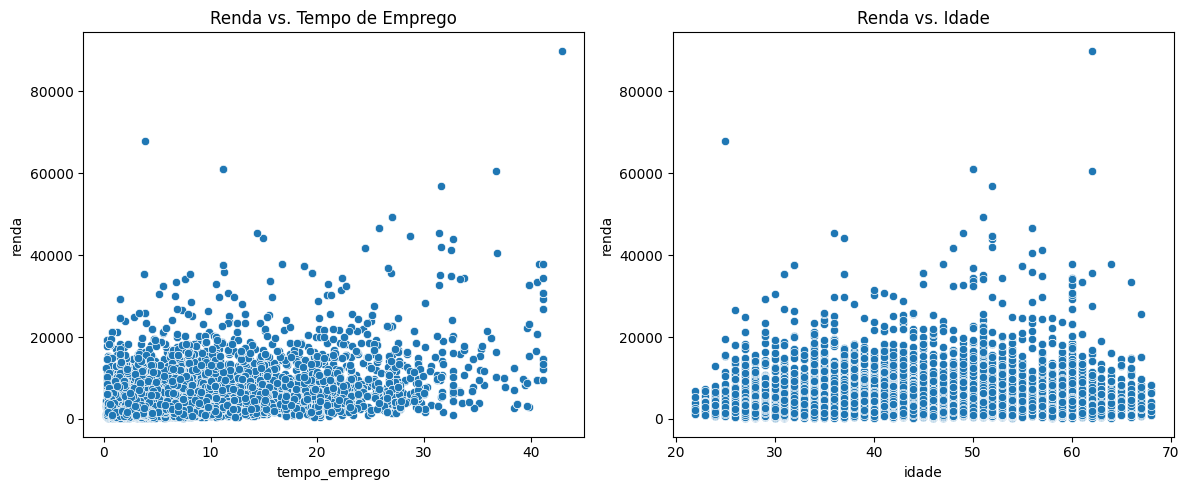

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='tempo_emprego', y='renda', data=df)
plt.title('Renda vs. Tempo de Emprego')

plt.subplot(1, 2, 2)
sns.scatterplot(x='idade', y='renda', data=df)
plt.title('Renda vs. Idade')

plt.tight_layout()
plt.show()

3) Na su aopinião, há outliers na variável renda?

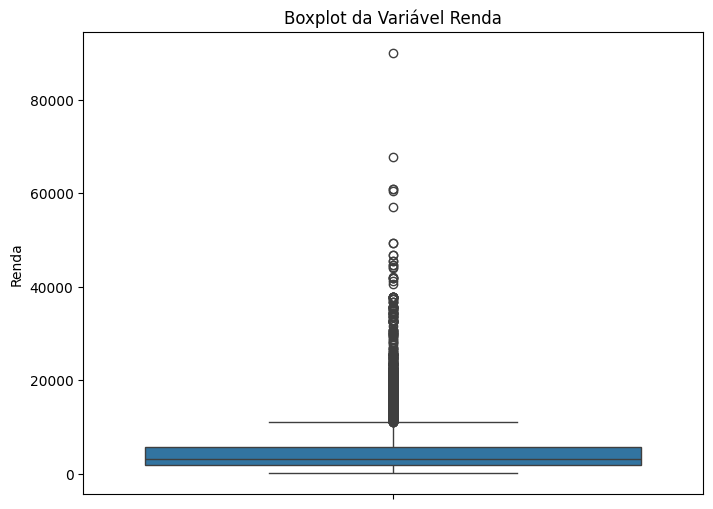

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['renda'])
plt.title('Boxplot da Variável Renda')
plt.ylabel('Renda')
plt.show()

4) Calcule o logaritmo da variável renda e repita a sequência de análise

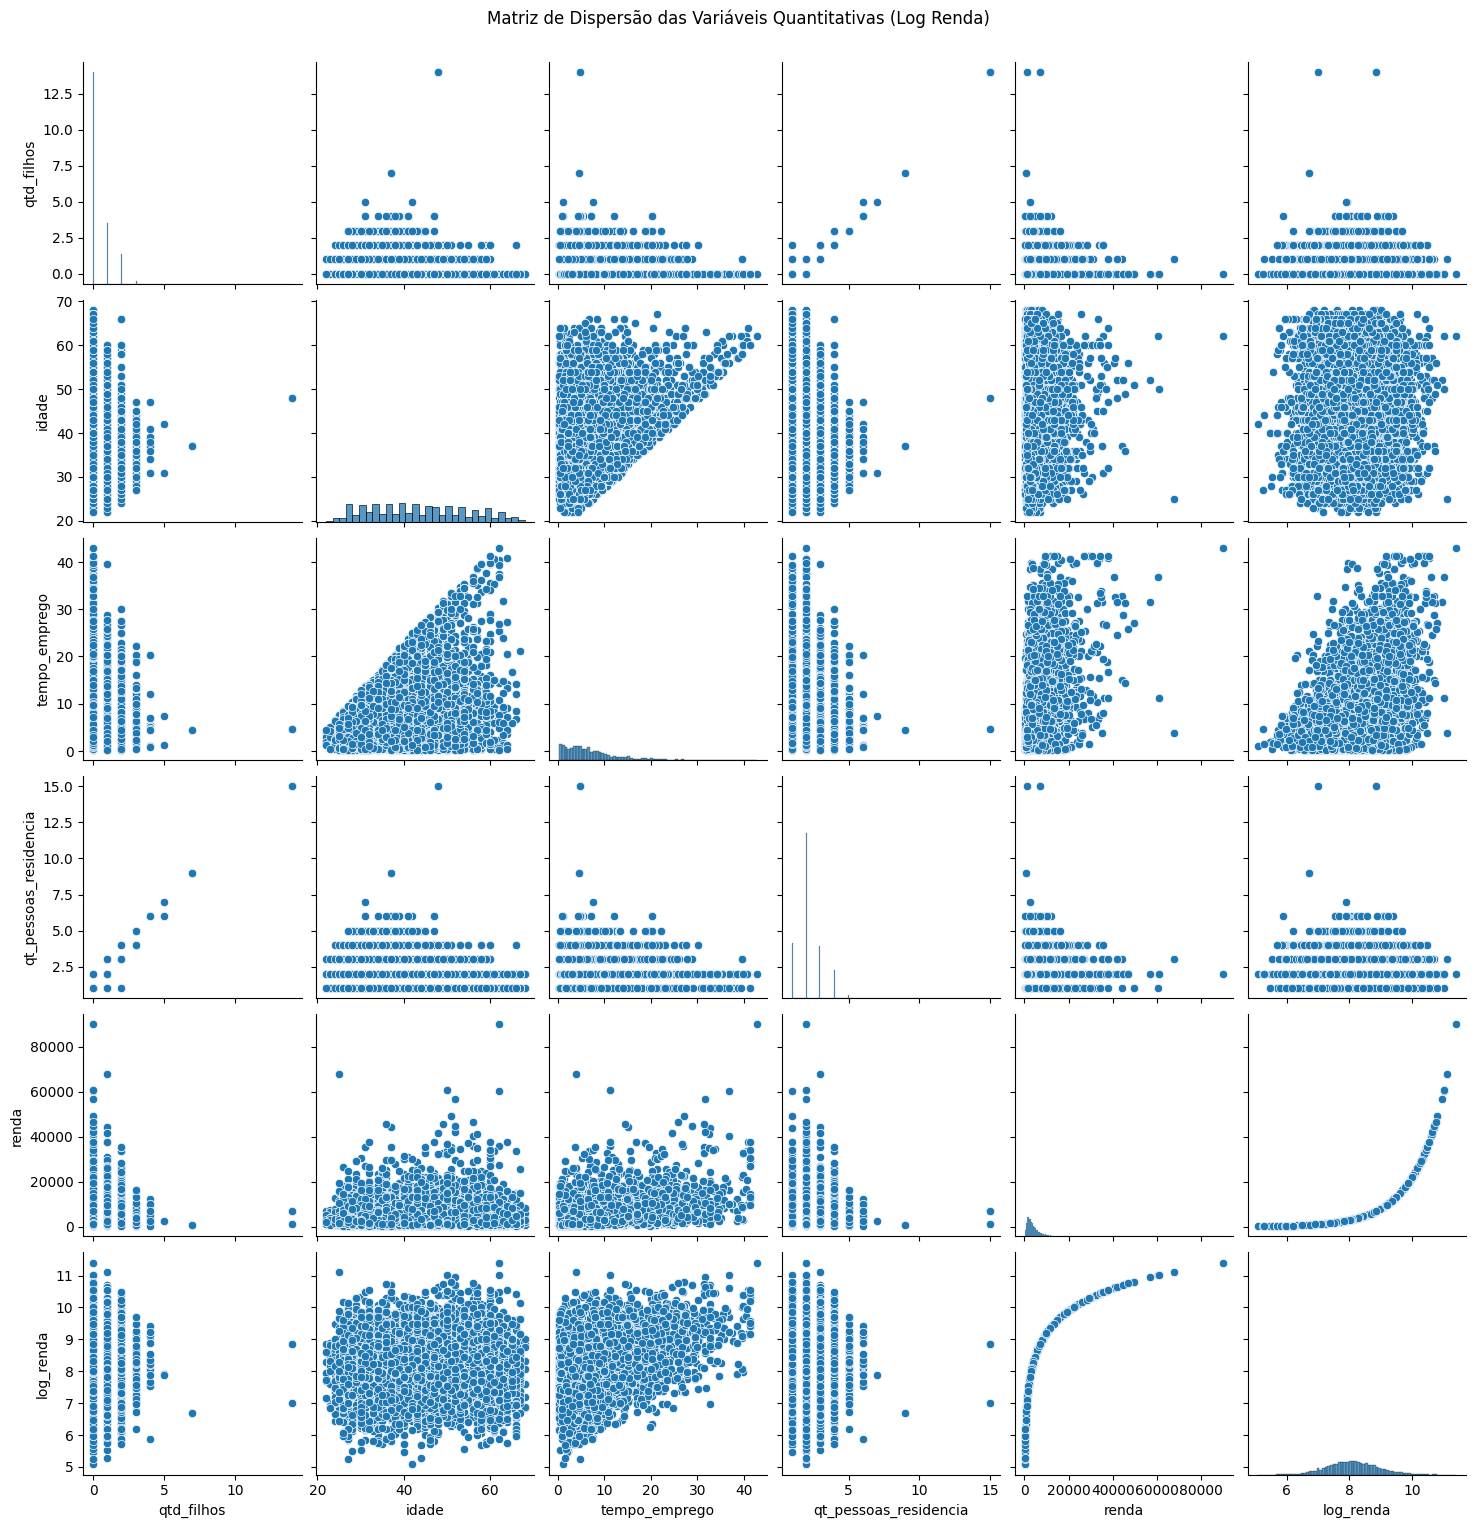

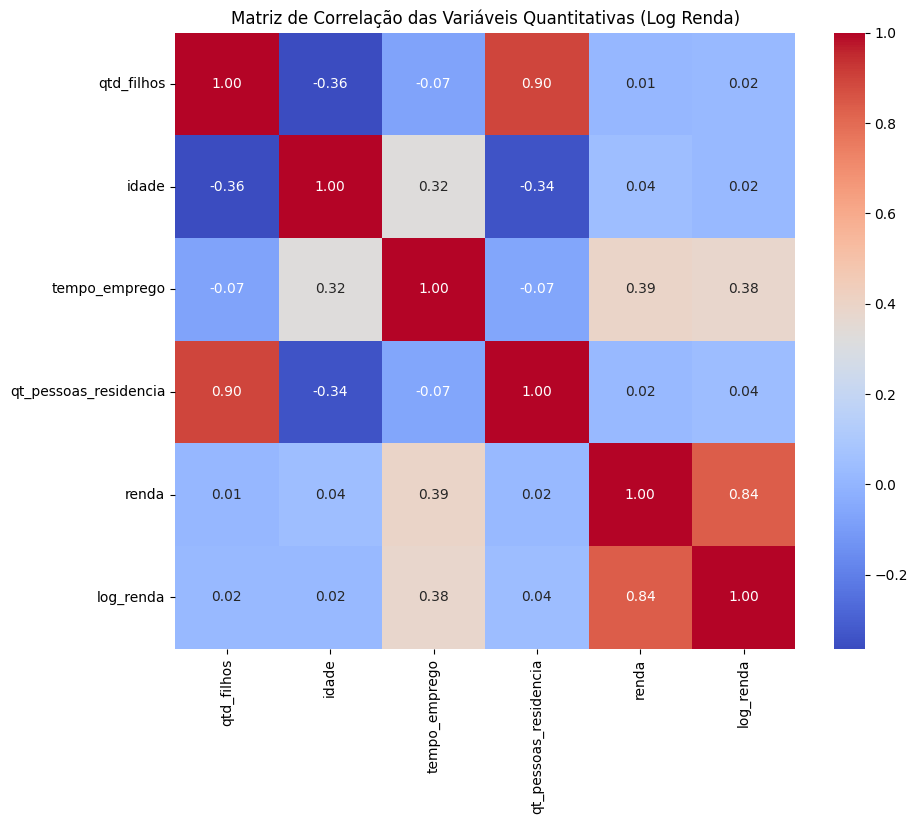

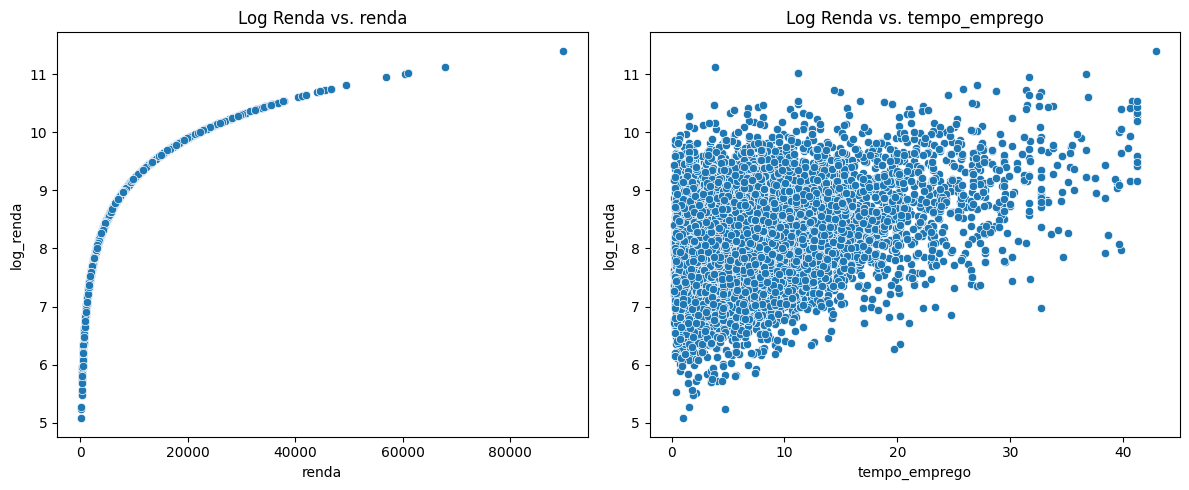

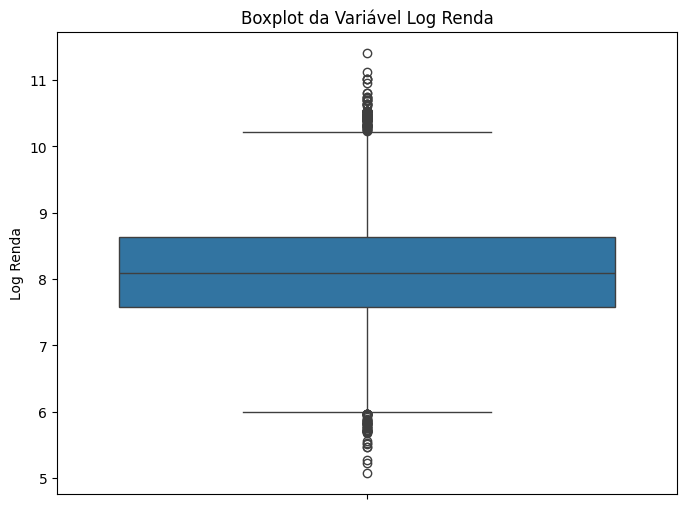

In [12]:
df['log_renda'] = np.log(df['renda'])

# Identify quantitative variables, including the new log_renda
quantitative_vars_log = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'index' as it's an identifier
if 'index' in quantitative_vars_log:
    quantitative_vars_log.remove('index')

# Calculate the correlation matrix with log_renda
corr_matrix_log = df[quantitative_vars_log].corr()

# Create a scatter matrix (pairplot) with log_renda
sns.pairplot(df[quantitative_vars_log])
plt.suptitle('Matriz de Dispersão das Variáveis Quantitativas (Log Renda)', y=1.02)
plt.show()

# Create a heatmap of the correlation matrix with log_renda
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_log, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Quantitativas (Log Renda)')
plt.show()

# Scatterplot for the two most correlated variables with log_renda
# Find the two variables most correlated with log_renda (excluding log_renda itself)
corr_with_log_renda = corr_matrix_log['log_renda'].drop('log_renda').abs().sort_values(ascending=False)
top_2_vars_log = corr_with_log_renda.head(2).index.tolist()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=top_2_vars_log[0], y='log_renda', data=df)
plt.title(f'Log Renda vs. {top_2_vars_log[0]}')

plt.subplot(1, 2, 2)
sns.scatterplot(x=top_2_vars_log[1], y='log_renda', data=df)
plt.title(f'Log Renda vs. {top_2_vars_log[1]}')

plt.tight_layout()
plt.show()

# Boxplot for log_renda
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['log_renda'])
plt.title('Boxplot da Variável Log Renda')
plt.ylabel('Log Renda')
plt.show()

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

A aplicação do LOG teve impacto positivo na análise. O boxplot da 'log_renda' mostra a distribuição muiot mais simétrica e com menos outliers.

A relação visual nos gráficos scatterplot parecem bem mais lineares depois da aplicação logarítimica.